<a href="https://colab.research.google.com/github/Bienbaz/Simple-Linear-Regression-Marketing-ROI-Analysis/blob/main/regression_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression – Marketing ROI Analysis

Upload `marketing_and_sales_data_evaluate_lr.csv` when prompted and run all cells.

In [2]:
# Upload dataset in Colab
try:
    from google.colab import files
    uploaded = files.upload()
except:
    print("If using Jupyter, place marketing_and_sales_data_evaluate_lr.csv in the same folder as this notebook.")


Saving marketing_and_sales_data_evaluate_lr.csv to marketing_and_sales_data_evaluate_lr (2).csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
sns.set_style("whitegrid")


In [4]:
df = pd.read_csv('marketing_and_sales_data_evaluate_lr.csv')
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.describe())


     TV      Radio  Social_Media       Sales
0  16.0   6.566231      2.907983   54.732757
1  13.0   9.237765      2.409567   46.677897
2  41.0  15.886446      2.913410  150.177829
3  83.0  30.020028      6.922304  298.246340
4  15.0   8.437408      1.405998   56.594181
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB
None
TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64
                TV        Radio  Social_Media        Sales
count  4562.000000  4568.000000   4566.000000  4566.000000
mean     54.066857    18.160356      3.323956   192.466602
std      26.125054     9.676958      2.212670    93.1

## Data Cleaning

In [5]:
df = df.dropna()
print("Dataset shape:", df.shape)


Dataset shape: (4546, 4)


## Exploratory Data Analysis

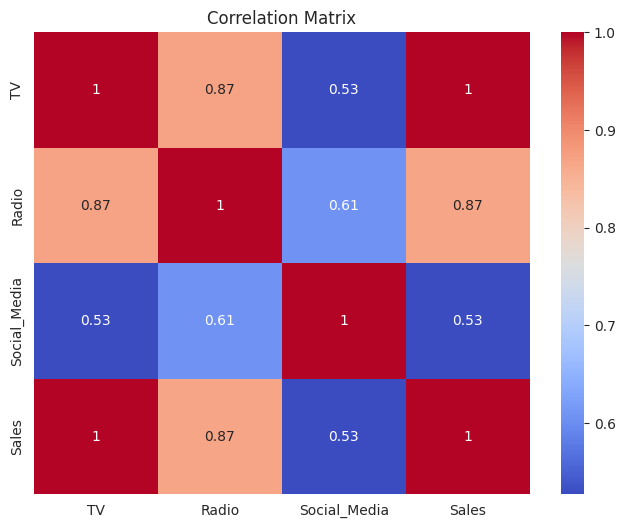

In [6]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


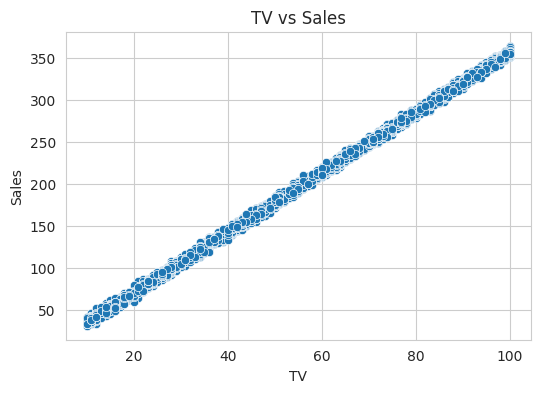

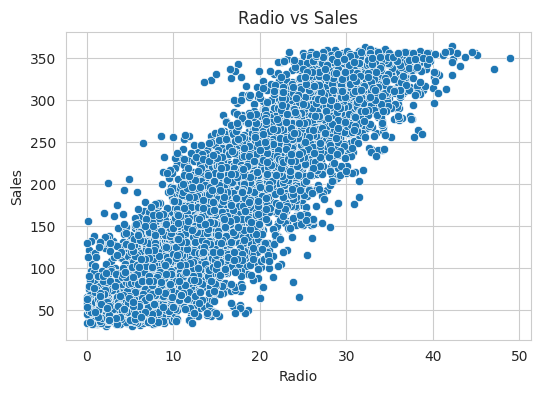

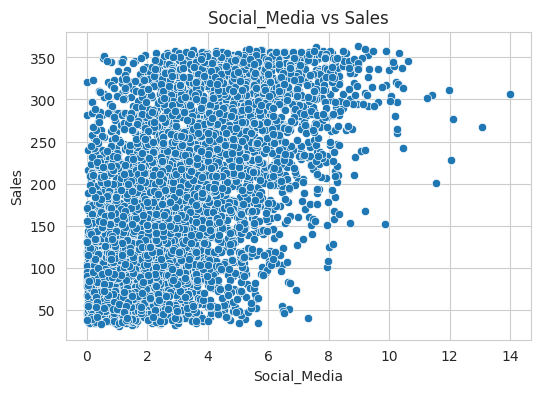

In [7]:
numeric_cols = [c for c in df.columns if c != 'Sales']
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=col, y='Sales')
    plt.title(f"{col} vs Sales")
    plt.show()


In [8]:
corr = df.corr(numeric_only=True)['Sales'].drop('Sales').sort_values(ascending=False)
print(corr)

best_feature = corr.index[0]
print("Selected feature:", best_feature)


TV              0.999497
Radio           0.868638
Social_Media    0.527446
Name: Sales, dtype: float64
Selected feature: TV


## Build OLS Regression Model

In [9]:
X = sm.add_constant(df[[best_feature]])
y = df['Sales']

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Mon, 15 Jun 2026   Prob (F-statistic):               0.00
Time:                        12:53:10   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

In [10]:
intercept = model.params.iloc[0]
coef = model.params.iloc[1]

print(f"Regression Equation: Sales = {intercept:.4f} + ({coef:.4f} × {best_feature})")


Regression Equation: Sales = -0.1325 + (3.5615 × TV)


## Diagnostic Plots

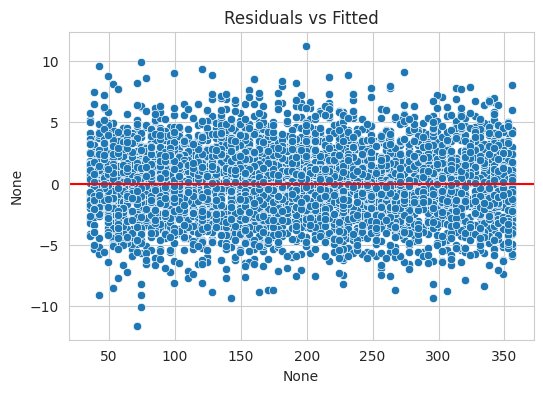

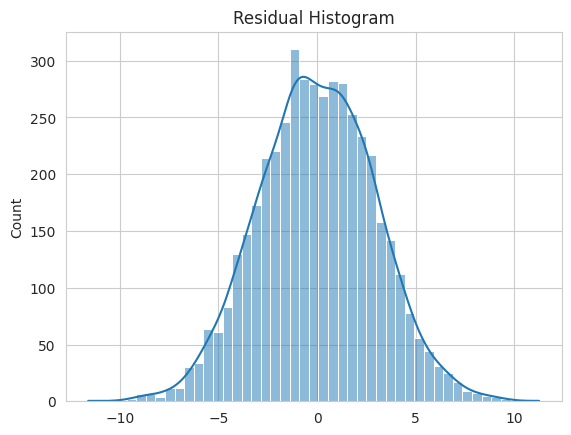

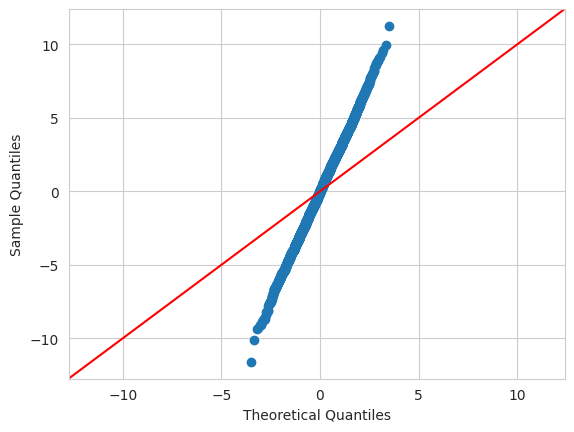

In [11]:
fitted = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0,color='red')
plt.title("Residuals vs Fitted")
plt.show()

sns.histplot(residuals, kde=True)
plt.title("Residual Histogram")
plt.show()

sm.qqplot(residuals, line='45')
plt.show()


## Interpretation and Recommendation

In [12]:
r2 = model.rsquared
pvalue = model.pvalues.iloc[1]

print("R-squared:", round(r2,4))
print("Coefficient:", round(coef,4))
print("P-value:", pvalue)

print("\nBusiness Recommendation")
print(f"The strongest marketing channel is {best_feature}.")
print("Allocate more budget to this channel because it shows the strongest statistical relationship with sales and is expected to provide the best ROI.")


R-squared: 0.999
Coefficient: 3.5615
P-value: 0.0

Business Recommendation
The strongest marketing channel is TV.
Allocate more budget to this channel because it shows the strongest statistical relationship with sales and is expected to provide the best ROI.
